In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [3]:
df = pd.read_csv("/content/GOOGL.csv")

In [4]:

df = df.sort_values('Date')

In [5]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602
5,2004-08-26,52.527527,54.029030,52.382381,54.009010,54.009010,7094898
6,2004-08-27,54.104103,54.364365,52.897900,53.128128,53.128128,6211782
7,2004-08-30,52.692692,52.797798,51.056057,51.056057,51.056057,5196798
8,2004-08-31,51.201202,51.906906,51.131130,51.236237,51.236237,4917877
9,2004-09-01,51.401402,51.536537,49.884884,50.175175,50.175175,9138253


In [6]:
print(df)

            Date         Open         High          Low        Close  \
0     2004-08-19    50.050049    52.082081    48.028027    50.220219   
1     2004-08-20    50.555557    54.594597    50.300301    54.209209   
2     2004-08-23    55.430431    56.796799    54.579578    54.754753   
3     2004-08-24    55.675674    55.855858    51.836838    52.487488   
4     2004-08-25    52.532532    54.054054    51.991993    53.053055   
...          ...          ...          ...          ...          ...   
4426  2022-03-18  2668.489990  2724.879883  2645.169922  2722.510010   
4427  2022-03-21  2723.270020  2741.000000  2681.850098  2722.030029   
4428  2022-03-22  2722.030029  2821.000000  2722.030029  2797.360107   
4429  2022-03-23  2774.050049  2791.770020  2756.699951  2765.510010   
4430  2022-03-24  2784.000000  2832.379883  2755.010010  2831.439941   

        Adj Close    Volume  
0       50.220219  44659096  
1       54.209209  22834343  
2       54.754753  18256126  
3       52.4874

In [7]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

In [8]:
print("Missing values before cleaning:\n", df.isnull().sum())


Missing values before cleaning:
 Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [9]:
df = df.dropna()

In [10]:
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [11]:
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

In [12]:
scaler = MinMaxScaler()

In [13]:
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [14]:
def create_dataset(data, time_step=100):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i])
        y.append(data[i, 3])  # Predict "Close"
    return np.array(X), np.array(y)

In [15]:

time_step = 100

In [16]:

X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)


In [17]:
model = Sequential()


In [18]:
model.add(Bidirectional(LSTM(100, return_sequences=True),
                        input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(100)))
model.add(Dropout(0.2))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.add(Dense(25, activation='relu'))
model.add(Dense(1))

In [20]:

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')


In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


In [22]:
history = model.fit(
    X_train, y_train,
    epochs=18,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=False,   # IMPORTANT for time series
    verbose=1
)

Epoch 1/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 46s 362ms/step - loss: 0.0020 - val_loss: 0.1699
Epoch 2/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 348ms/step - loss: 0.0016 - val_loss: 0.1207
Epoch 3/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 354ms/step - loss: 0.0010 - val_loss: 0.0749
Epoch 4/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 355ms/step - loss: 0.0013 - val_loss: 0.0308
Epoch 5/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 356ms/step - loss: 0.0013 - val_loss: 0.0097
Epoch 6/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 356ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 7/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 40s 372ms/step - loss: 0.0015 - val_loss: 0.0100
Epoch 8/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 40s 372ms/step - loss: 0.0011 - val_loss: 0.0170
Epoch 9/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 358ms/step - loss: 9.3402e-04 - val_loss: 0.0041
Epoch 10/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 358ms/step - loss: 7.3853e-04 - val_loss: 0.0058
Epoch 11/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 349ms/step - loss: 9.1525e-04 - val_loss: 0.0082
Epoch 1

In [23]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step


In [24]:
def inverse_transform(pred, data):
    temp = np.zeros((len(pred), data.shape[1]))
    temp[:, 3] = pred[:, 0]  # Close column
    return scaler.inverse_transform(temp)[:, 3]

In [25]:
train_pred_actual = inverse_transform(train_pred, train_scaled)
y_train_actual = inverse_transform(y_train.reshape(-1, 1), train_scaled)

In [26]:
test_pred_actual = inverse_transform(test_pred, test_scaled)
y_test_actual = inverse_transform(y_test.reshape(-1, 1), test_scaled)

In [27]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred_actual))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))

In [28]:
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)


Train RMSE: 83.12236251943744
Test RMSE: 67.21084660584913


In [29]:
plt.figure(figsize=(14,6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

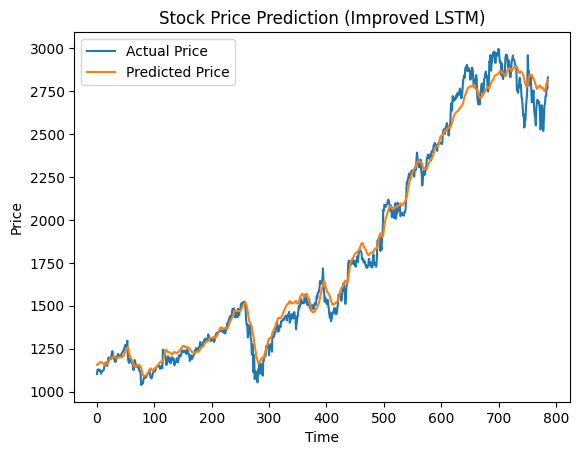

In [30]:
plt.plot(y_test_actual, label="Actual Price")
plt.plot(test_pred_actual, label="Predicted Price")
plt.title("Stock Price Prediction (Improved LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()